# 로그변환 > 상관관계 높은기준 이상치 제거 > SMOTE(TRAIN에만)

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

card_df=pd.read_csv('creditcard.csv')

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def get_preprocessed_df(df=None):
    df_copy=df.copy()
    scaler=StandardScaler()
    amount_n=scaler.fit_transform(df_copy[['Amount']])
    df_copy.insert(0,'Amount_Scaled',amount_n)
    df_copy.drop(['Time','Amount'],axis=1,inplace=True)
    return df_copy

def get_train_test_dataset(df=None):
    df_copy=get_preprocessed_df(df)
    X_features=df_copy.iloc[:,:-1]
    y_target=df_copy.iloc[:,-1]
    X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.3,stratify=df.iloc[:,-1])
    return X_train,X_test,y_train,y_test

X_train,X_test,y_train,y_test =get_train_test_dataset(card_df)

In [15]:
print(y_train.value_counts()/y_train.count())
print(y_test.value_counts()/y_test.count())

Class
0    0.998275
1    0.001725
Name: count, dtype: float64
Class
0    0.998268
1    0.001732
Name: count, dtype: float64


In [32]:
# 로지스틱회귀
from sklearn.linear_model import LogisticRegression

lr_clf=LogisticRegression(max_iter=100)
lr_clf.fit(X_train,y_train)
lr_pred=lr_clf.predict(X_test)
lr_pred_proba=lr_clf.predict_proba(X_test)[:,1]

get_clf_eval(y_test,lr_pred,lr_pred_proba)
# amount변환후 정밀도와 재현율이 조금저하됨

오차 행렬
[[85244    51]
 [   58    90]]
정확도: 0.9987, 정밀도: 0.6383, 재현율: 0.6081,    F1: 0.6228, AUC:0.8739


C:\Users\rhals\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
#lightgbm

def get_model_train_eval(model,ftr_train=None,ftr_test=None,tgt_train=None,tgt_test=None):
    model.fit(ftr_train,tgt_train)
    pred=model.predict(ftr_test)
    pred_proba=model.predict_proba(ftr_test)[:,1]
    get_clf_eval(tgt_test,pred,pred_proba)

In [33]:
from lightgbm import LGBMClassifier

lgbm_clf=LGBMClassifier(n_estimators=1000,num_leaves=64,n_jobs=-1, boost_from_average=False)
# boost_from_averag 극단적으로 불균형한 데이터에서 초기 예측시작값을 평균으로 하지 않기위함, true설정시 평균에서 출발해 학습이 빠름,
# 다만 평균이 편향으로 작동해서 가중치 파라미터의 효과가 희석될 수 있음
get_model_train_eval(lgbm_clf,ftr_train=X_train,ftr_test=X_test,tgt_train=y_train,tgt_test=y_test)
# amount변환후 정밀도와 재현율이 조금 저하됨

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

# 분포도 변환후, 학습/예측

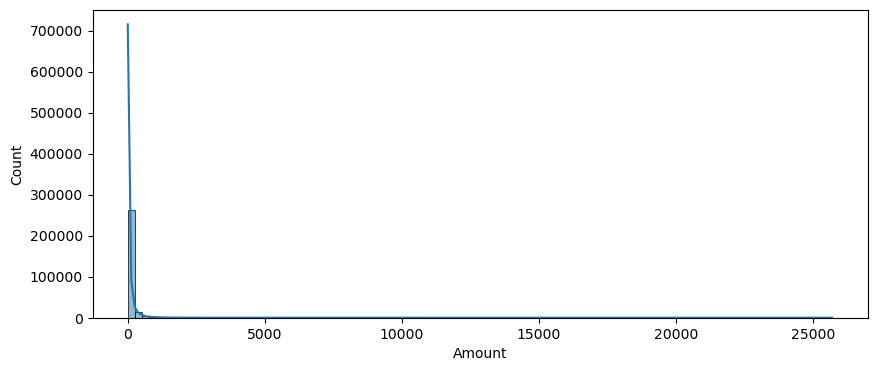

In [24]:

# 대부분의 선형 모델은 중요 핓들의 값이 정규 분포 형태를 유지하는 것을 선호한다.

import seaborn as sns

plt.figure(figsize=(10,4))
sns.histplot(card_df['Amount'],bins=100,kde=True)
plt.show()

In [ ]:
# 선형모델이 정규분포를 선호한다
#1.피처간의 스케일이 비슷한것 비슷하지 않으면 경사하강법 수렴이 느려지고,정규화 패널티가 불공정해짐 => standardscaler로  스케일을 공평하게
#  피처의 분포를 바꾸진 못함,스케일만 변환
#2.선형회귀의 가정 잔차의 정규성 : 실제로 분포를 정규분포에 가깝도록 바꿈

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

def get_preprocessed_df(df=None):
    df_copy=df.copy()
    scaler=StandardScaler()
    amount_n=np.log1p(df_copy['Amount'])
    df_copy.insert(0,'Amount_Scaled',amount_n)
    df_copy.drop(['Time','Amount'],axis=1,inplace=True)
    return df_copy

def get_train_test_dataset(df=None):
    df_copy=get_preprocessed_df(df)
    X_features=df_copy.iloc[:,:-1]
    y_target=df_copy.iloc[:,-1]
    X_train,X_test,y_train,y_test=train_test_split(X_features,y_target,test_size=0.3,stratify=y_target,random_state=42)
    return X_train,X_test,y_train,y_test

X_train,X_test,y_train,y_test =get_train_test_dataset(card_df)

In [64]:
# 로지스틱 
# 레이블이 극도로 불안정한 경우, 특정피처의 정규분포형태를 띄게하기위한 변환 수행시 , 약간은 불안정한 성능결과
print('로지스틱예측')
get_model_train_eval(lr_clf,ftr_train=X_train,ftr_test=X_test,tgt_train=y_train,tgt_test=y_test)

#lightgbm
print('lightgbm예측')
get_model_train_eval(lgbm_clf,ftr_train=X_train,ftr_test=X_test,tgt_train=y_train,tgt_test=y_test)

로지스틱예측
오차 행렬
[[85280    15]
 [   55    93]]
정확도: 0.9992, 정밀도: 0.8611, 재현율: 0.6284,    F1: 0.7266, AUC:0.9560
lightgbm예측
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

# 이상치 제거후  모델학습/예측/평가

* 피처와 타겟의 상관관계가 높은것 우선으로 이상치제거, 상관관계가 없는경우 이상치 제거해도 의미가 거의없음

<Axes: >

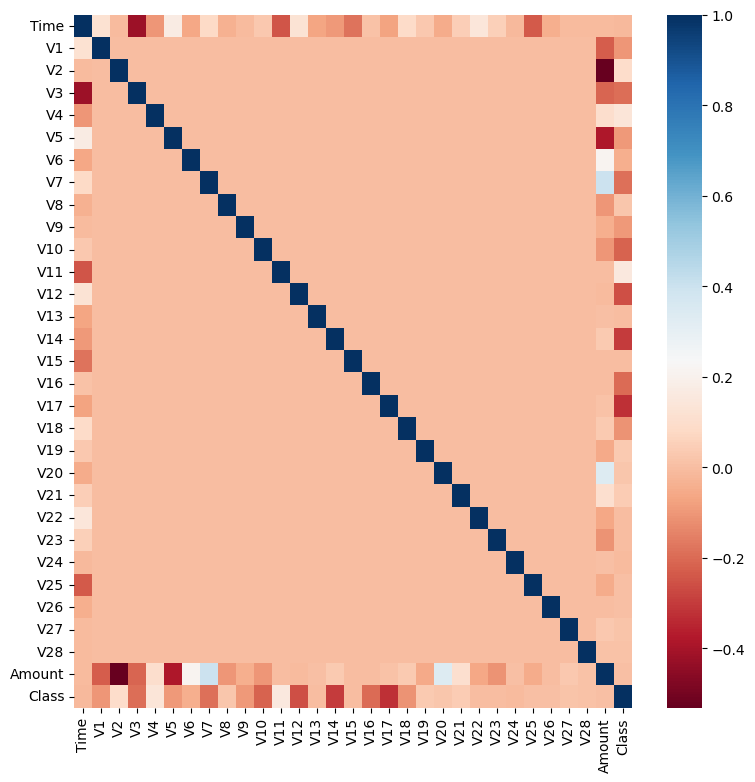

In [39]:
import seaborn as sns

plt.figure(figsize=(9,9))
corr=card_df.corr()
sns.heatmap(corr,cmap='RdBu')

In [47]:
def get_outlier(df=None,column=None,weight=1.5):
    #사기 케이스안에서 극단치를 제거하기위함, 데이터 자체가 매우 불균형해서 정상거래의 분포가 이상치를 묻어버릴수있음
    fraud=df[df['Class']==1][column]
    quantile_25=np.percentile(fraud.values,25)
    quantile_75=np.percentile(fraud.values,75)

    iqr=quantile_75-quantile_25
    iqr_weight=iqr*weight
    lowest_val=quantile_25-iqr_weight
    highest_val=quantile_75+iqr_weight

    outlier_index=fraud[(fraud<lowest_val)|(fraud>highest_val)].index
    return outlier_index

In [48]:
get_outlier(df=card_df,column='V14',weight=1.5)

Index([8296, 8615, 9035, 9252], dtype='int64')

In [65]:
#로그변환후 이상치제거 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

def get_preprocessed_df(df=None):
    df_copy=df.copy()
    scaler=StandardScaler()
    amount_n=np.log1p(df_copy['Amount'])
    df_copy.insert(0,'Amount_Scaled',amount_n)
    df_copy.drop(['Time','Amount'],axis=1,inplace=True)
    outlier_index=get_outlier(df=df_copy,column='V14',weight=1.5)
    df_copy.drop(outlier_index,axis=0,inplace=True)
    return df_copy

def get_train_test_dataset(df=None):
    df_copy=get_preprocessed_df(df)
    X_features=df_copy.iloc[:,:-1]
    y_target=df_copy.iloc[:,-1]
    X_train,X_test,y_train,y_test=train_test_split(X_features,y_target,test_size=0.3,stratify=y_target,random_state=42)
    return X_train,X_test,y_train,y_test

X_train,X_test,y_train,y_test =get_train_test_dataset(card_df)

print('로지스틱예측')
get_model_train_eval(lr_clf,ftr_train=X_train,ftr_test=X_test,tgt_train=y_train,tgt_test=y_test)

#lightgbm
print('lightgbm예측')
get_model_train_eval(lgbm_clf,ftr_train=X_train,ftr_test=X_test,tgt_train=y_train,tgt_test=y_test)

로지스틱예측
오차 행렬
[[85281    14]
 [   52    94]]
정확도: 0.9992, 정밀도: 0.8704, 재현율: 0.6438,    F1: 0.7402, AUC:0.9757
lightgbm예측
[LightGBM] [Info] Number of positive: 342, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199362, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [66]:
# 전처리 >스케일, 로그변환 같은 정규분포형태요구고려 , 상관관계확인후 높은 것 위주로 이상치 제거

# smote 오버 샘플링

* 상대적으로 적은 데이터를 증식시키는데, k최근접 이웃으로 비슷하게 만들어진 데이터로 증식시킴)
* 반드시 학습데이터만 oversampling할것

In [70]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)

X_train_over,y_train_over=smote.fit_resample(X_train,y_train)
print('smote 전 :',X_train.shape,y_train.shape)
print('smote 후 :',X_train_over.shape,y_train_over.shape)
print('적용후 분포:',y_train_over.value_counts()/y_train_over.count())

smote 전 : (199362, 29) (199362,)
smote 후 : (398040, 29) (398040,)
적용후 분포: Class
0    0.5
1    0.5
Name: count, dtype: float64


데이터 크기	시작점으로 많이 쓰는 값
작은 데이터 (수천 행, 피처 몇십 개)	기본값 100 ~ 200으로 충분한 경우 많음
중간 규모 (수만 ~ 수십만 행)	1000 정도로 시작
크고 피처 많은 데이터 (지금 fraud 데이터처럼 28만 행, V1 ~ V28)	1000 ~ 5000

In [73]:
print('로지스틱예측')
lr_clf=LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,ftr_train=X_train_over,ftr_test=X_test,tgt_train=y_train_over,tgt_test=y_test)
#매우 저조한 정밀도 > 분류 결정 임계값을 수정하자

로지스틱예측
오차 행렬
[[83301  1994]
 [   16   130]]
정확도: 0.9765, 정밀도: 0.0612, 재현율: 0.8904,    F1: 0.1145, AUC:0.9693


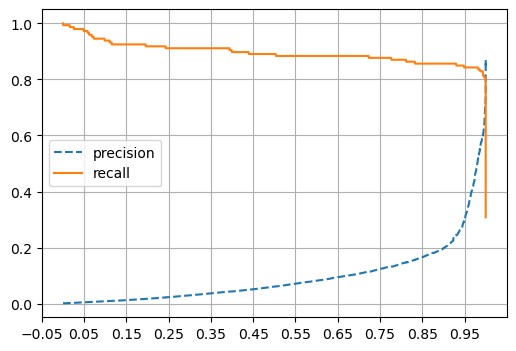

In [76]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_recall_curve

def precision_recall_curve_plot(y_test,pred_proba):
    precision,recall,threshold=precision_recall_curve(y_test,pred_proba)

    # x축을 threshold값, y축은 정밀도, 재현율 값으로  plot 실행
    plt.figure(figsize=(6,4))
    threshold_boundary=threshold.shape[0]
    plt.plot(threshold,precision[0:threshold_boundary],label='precision',linestyle='--')
    plt.plot(threshold,recall[0:threshold_boundary],label='recall')

    # threshold 값 X 축의 Scale을 0.1로 변겅
    start,end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))

    # x축,y축 label과 legend, 그리고 grid 설정
    plt.grid()
    plt.legend()
    plt.show()

precision_recall_curve_plot(y_test,lr_clf.predict_proba(X_test)[:,1])

In [ ]:
# 임계값에 따른 지표의 민감도가 너무심해서 , 특정한 값을 고를수가없다.

In [77]:
get_model_train_eval(lgbm_clf,ftr_train=X_train_over,ftr_test=X_test,tgt_train=y_train_over,tgt_test=y_test)
# smote를 적용시 재현율은 올라가는데, 정밀도는 떨어지는게 정상임 trade off , 재현율 지표를 올리는게 목적이라면 ,smote를적용하는게 좋음

[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split